# 1 — Setup & Data Loading

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [2]:
try:
    import imblearn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '--quiet'])
    import imblearn
print('imbalanced-learn', imblearn.__version__)


imbalanced-learn 0.14.2


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
try:
    df= pd.read_csv('/content/drive/MyDrive/NTI/task/healthcare-dataset-stroke-data.csv')
except FileNotFoundError:
    df= pd.read_csv('healthcare-dataset-stroke-data.csv')


## 2 — Exploratory Data Analysis (Raw)

In [5]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [7]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
numcol=['age','avg_glucose_level','bmi']
catcol=['gender','ever_married','work_type','Residence_type','smoking_status','heart_disease','stroke']

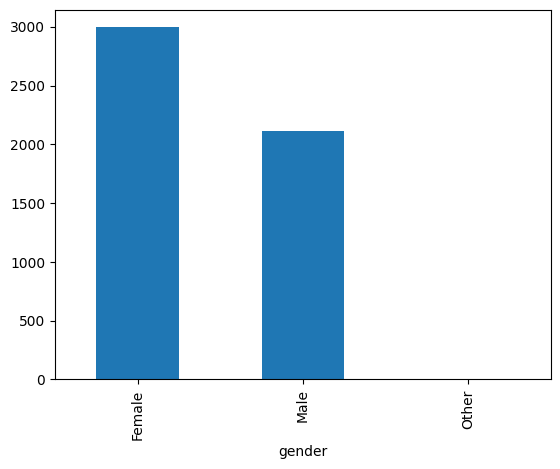

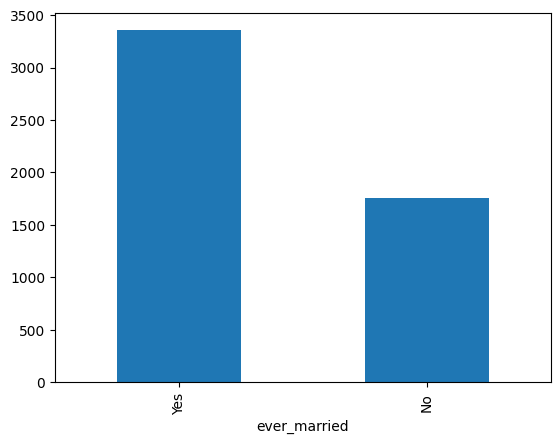

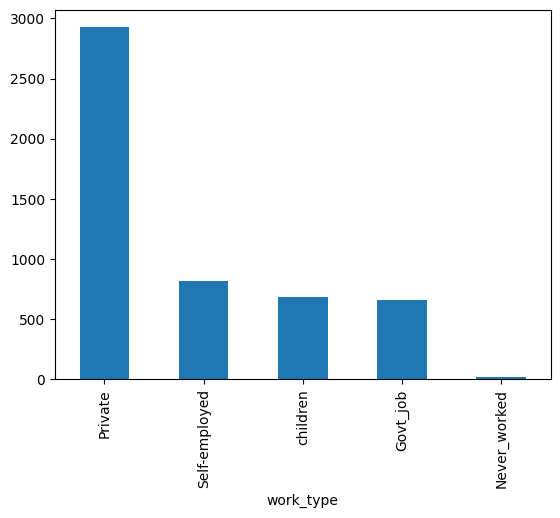

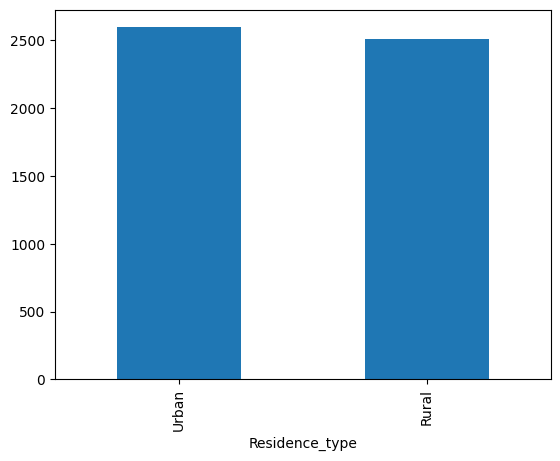

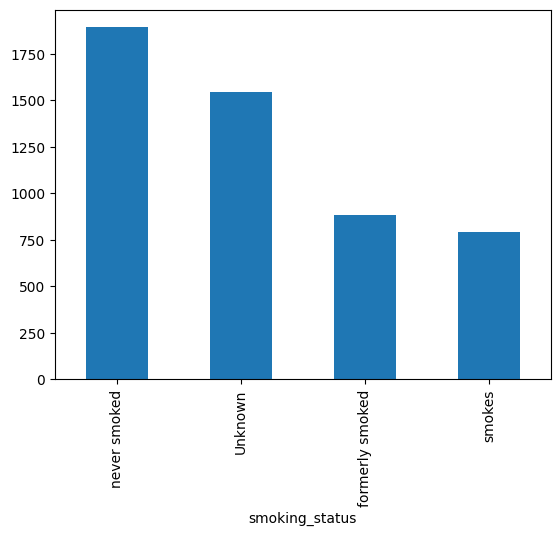

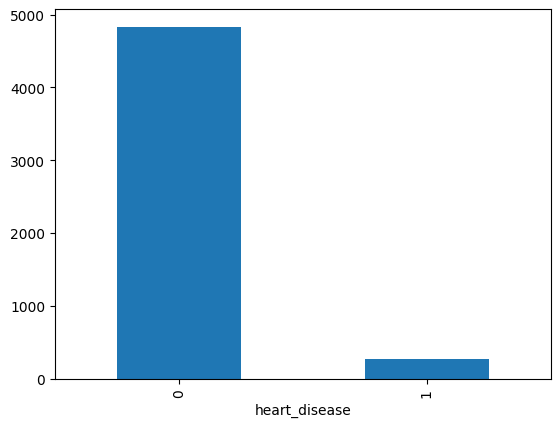

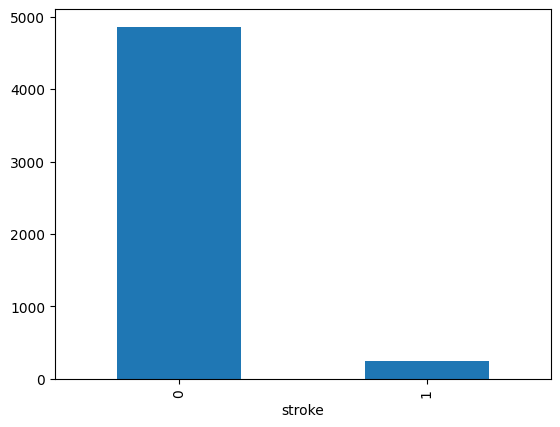

In [11]:
for col in catcol:
  df[col].value_counts().plot(kind='bar')
  plt.show()

<Axes: >

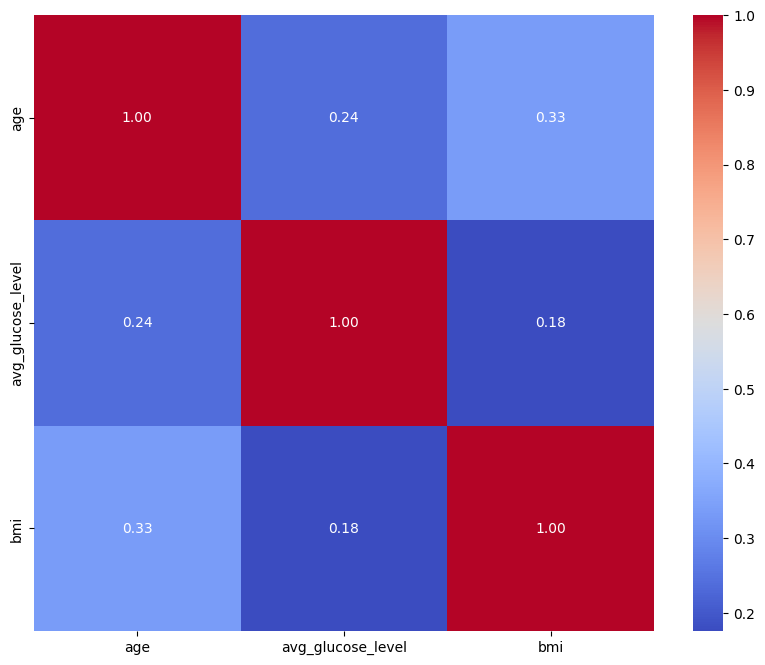

In [12]:
corr =df[numcol].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

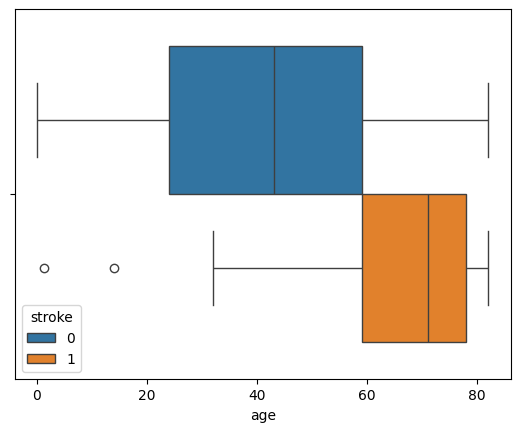

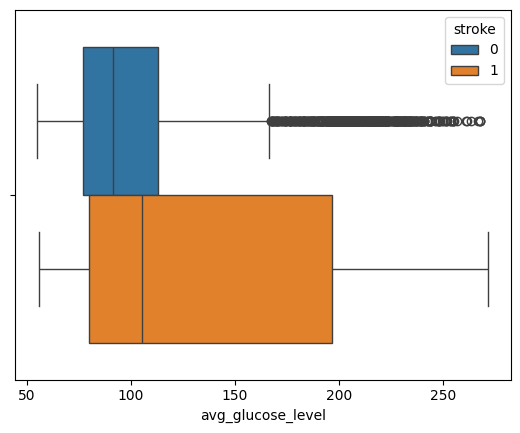

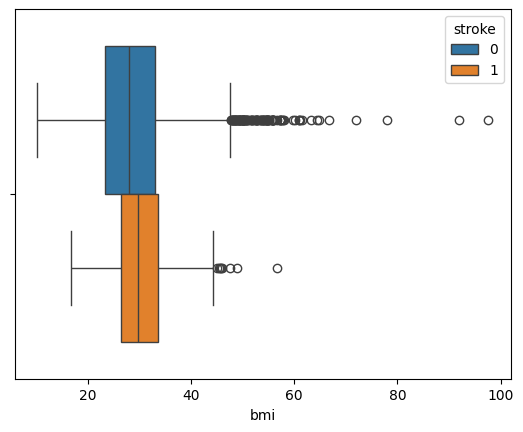

In [13]:

for col in numcol:
  sns.boxplot(data=df,x=col,hue="stroke")
  plt.show()

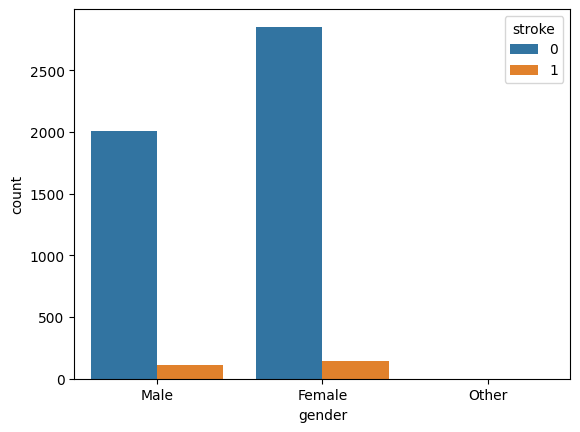

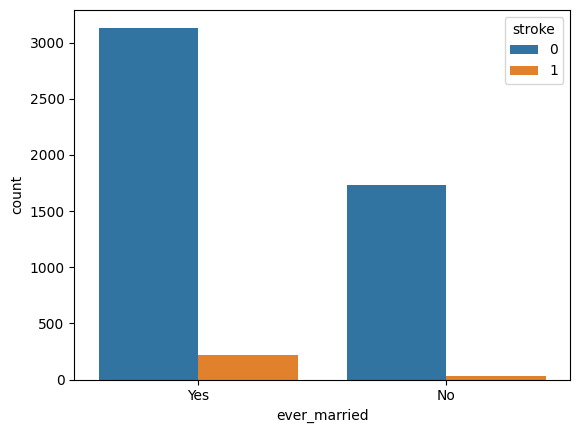

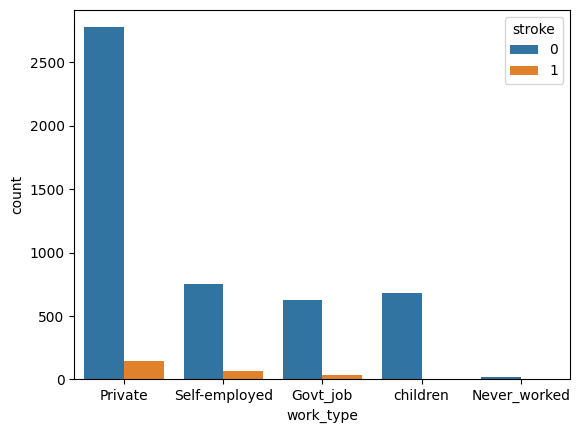

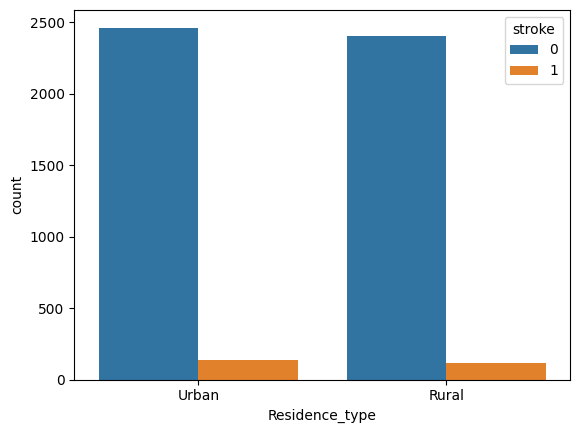

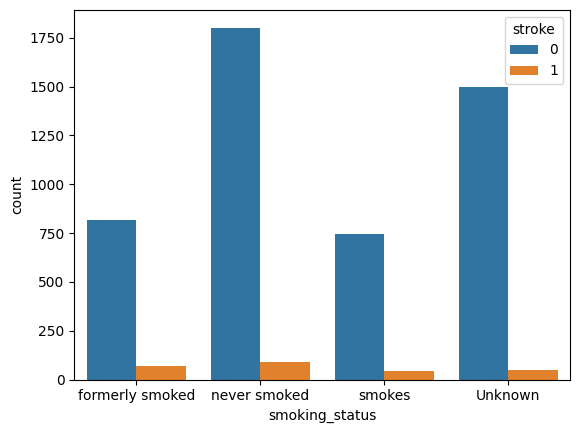

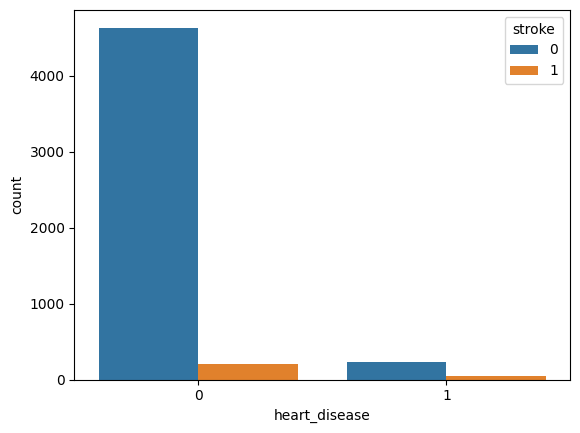

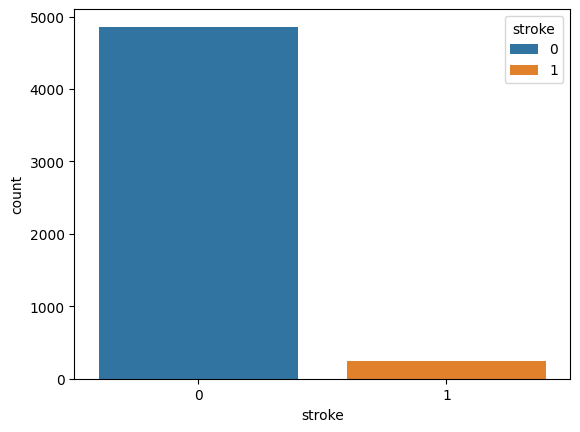

In [14]:
for col in catcol:
  sns.countplot(data=df,x=col,hue="stroke")
  plt.show()

## 3 — Data Cleaning

In [15]:
df.drop(columns=['id'], inplace=True)

In [16]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())


In [17]:
print('gender before:', df['gender'].value_counts().to_dict())
df.drop(df[df['gender'] == 'Other'].index, inplace=True)
print('gender after:', df['gender'].value_counts().to_dict())


gender before: {'Female': 2994, 'Male': 2115, 'Other': 1}
gender after: {'Female': 2994, 'Male': 2115}


In [18]:
df.loc[(df['smoking_status'] == 'Unknown') & (df['age'] < 15), 'smoking_status'] = 'never smoked'
mode_value = df.loc[df['smoking_status'] != 'Unknown', 'smoking_status'].mode()[0]
df.loc[df['smoking_status'] == 'Unknown', 'smoking_status'] = mode_value

In [19]:
df['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes'], dtype=object)

In [20]:
print('smoking_status after cleaning:', df['smoking_status'].value_counts().to_dict())
print('Unknown remaining:', (df['smoking_status']=='Unknown').sum())
assert (df['smoking_status']=='Unknown').sum()==0, 'Unknown still present!'
df.info()


smoking_status after cleaning: {'never smoked': 3436, 'formerly smoked': 884, 'smokes': 789}
Unknown remaining: 0
<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB


## 4 — Feature Engineering

In [21]:
df['log_age'] = np.log1p(df['age'])
df['log_bmi'] = np.log1p(df['bmi'])
df['log_glucose'] = np.log1p(df['avg_glucose_level'])

In [22]:
df['bmi_glucose_interaction'] = df['log_bmi'] * df['log_age']
df['high_risk_elderly'] = ((df['age'] > 65) & ((df['hypertension'] == 1) | (df['heart_disease'] == 1))).astype(int)
df['risk_factor_count'] = df['hypertension'] + df['heart_disease'] + (df['age'] > 65).astype(int)

In [23]:
df.drop(columns=['age', 'bmi', 'avg_glucose_level'], inplace=True)

In [24]:
print(df.columns.tolist())
print(df[['log_age','log_bmi','log_glucose','bmi_glucose_interaction','high_risk_elderly','risk_factor_count']].head())


['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke', 'log_age', 'log_bmi', 'log_glucose', 'bmi_glucose_interaction', 'high_risk_elderly', 'risk_factor_count']
    log_age   log_bmi  log_glucose  bmi_glucose_interaction  \
0  4.219508  3.627004     5.436731                15.304172   
1  4.127134  3.370738     5.314240                13.911489   
2  4.394449  3.511545     4.672081                15.431308   
3  3.912023  3.566712     5.148831                13.953059   
4  4.382027  3.218876     5.165471                14.105200   

   high_risk_elderly  risk_factor_count  
0                  1                  2  
1                  0                  0  
2                  1                  2  
3                  0                  0  
4                  1                  2  


## 5 — Train/Test Split & Preprocessing

In [25]:
x = df.drop('stroke', axis=1)

y = df['stroke']

In [26]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (4087, 13)
Testing data: (1022, 13)


In [27]:
cat_feture=['gender',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status']
num_feture=['log_age',
 'log_bmi',
 'log_glucose',
 'bmi_glucose_interaction',
 'high_risk_elderly',
 'risk_factor_count']

In [28]:

preprocessor = ColumnTransformer(
    transformers=[
        ('robust', StandardScaler(), num_feture),
        ('onehot', OneHotEncoder(handle_unknown='ignore'),cat_feture)
    ],
    remainder='passthrough'
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [29]:
x_train_processed=pd.DataFrame(x_train_processed,columns=preprocessor.get_feature_names_out())
x_test_processed=pd.DataFrame(x_test_processed,columns=preprocessor.get_feature_names_out())

In [30]:
x_train_processed

,robust__log_age,robust__log_bmi,robust__log_glucose,robust__bmi_glucose_interaction,robust__high_risk_elderly,robust__risk_factor_count,onehot__gender_Female,onehot__gender_Male,onehot__ever_married_No,onehot__ever_married_Yes,...,onehot__work_type_Private,onehot__work_type_Self-employed,onehot__work_type_children,onehot__Residence_type_Rural,onehot__Residence_type_Urban,onehot__smoking_status_formerly smoked,onehot__smoking_status_never smoked,onehot__smoking_status_smokes,remainder__hypertension,remainder__heart_disease
0,0.400642,0.656384,-0.988690,0.526910,-0.275335,-0.537129,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,-0.190350,-1.053189,-0.443690,-0.489022,-0.275335,-0.537129,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.029270,-0.759291,0.531189,-0.224920,-0.275335,-0.537129,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.125687,0.609385,0.268394,0.256698,-0.275335,-0.537129,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.025297,0.477203,-0.505562,-0.841847,-0.275335,-0.537129,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4082,0.324538,0.883403,-0.170560,0.525395,-0.275335,-0.537129,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4083,-0.874529,-1.370514,0.388856,-1.121406,-0.275335,-0.537129,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4084,0.684095,1.002960,-0.633184,0.905606,-0.275335,-0.537129,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4085,-0.112608,-0.273516,-0.800826,-0.209371,-0.275335,-0.537129,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [31]:
print('Train:', x_train_processed.shape, ' Test:', x_test_processed.shape)
print(list(preprocessor.get_feature_names_out())[:12])


Train: (4087, 22)  Test: (1022, 22)
['robust__log_age', 'robust__log_bmi', 'robust__log_glucose', 'robust__bmi_glucose_interaction', 'robust__high_risk_elderly', 'robust__risk_factor_count', 'onehot__gender_Female', 'onehot__gender_Male', 'onehot__ever_married_No', 'onehot__ever_married_Yes', 'onehot__work_type_Govt_job', 'onehot__work_type_Never_worked']


## 6 — Baseline Modeling (class_weight='balanced')

In [32]:
model= LogisticRegression()
model.fit(x_train_processed,y_train)
y_pred_train=model.predict(x_train_processed)
y_pred_test=model.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))
print("R2 Score:", model.score(x_test_processed, y_test))

Training Accuracy: 0.951309028627355
Testing Accuracy: 0.9510763209393346
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

R2 Score: 0.9510763209393346


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


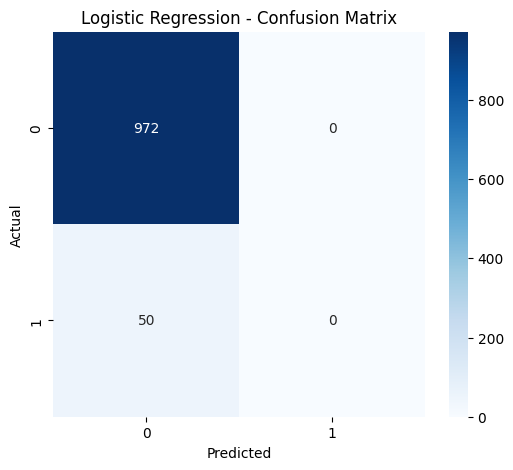

In [33]:
cm_logistic = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [34]:
model= LogisticRegression(class_weight='balanced')
model.fit(x_train_processed,y_train)
y_pred_train=model.predict(x_train_processed)
y_pred_test=model.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))
print("R2 Score:", model.score(x_test_processed, y_test))

Training Accuracy: 0.7220455101541473
Testing Accuracy: 0.7181996086105675
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.71      0.83       972
           1       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.52      1022
weighted avg       0.94      0.72      0.80      1022

R2 Score: 0.7181996086105675


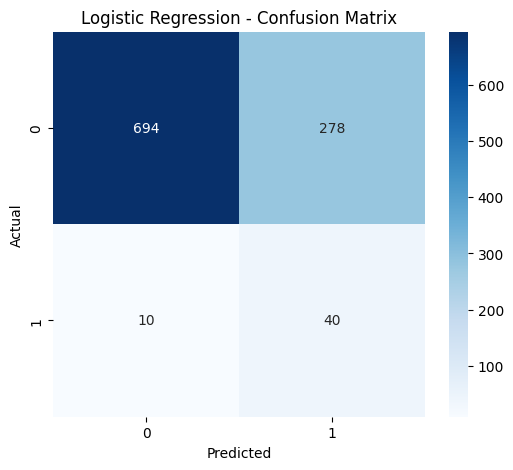

In [35]:
cm_logistic = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [36]:
model_svc2 = SVC(kernel='linear',C=1,class_weight='balanced')
model_svc2.fit(x_train_processed,y_train)
y_pred_train_svc2=model_svc2.predict(x_train_processed)
y_pred_test_svc2=model_svc2.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc2))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc2))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc2))
print("R2 Score:", model_svc2.score(x_test_processed, y_test))

Training Accuracy: 0.7619280645950575
Testing Accuracy: 0.7759295499021527
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.78      0.87       972
           1       0.15      0.74      0.24        50

    accuracy                           0.78      1022
   macro avg       0.56      0.76      0.56      1022
weighted avg       0.94      0.78      0.84      1022

R2 Score: 0.7759295499021527


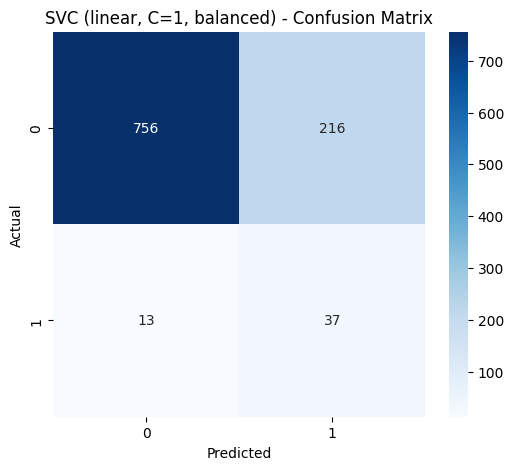

In [37]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (linear, C=1, balanced) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [104]:
model_svc3 = SVC(kernel='poly',degree=4,C=1, gamma='scale',class_weight='balanced')
model_svc3.fit(x_train_processed,y_train)
y_pred_train_svc3=model_svc3.predict(x_train_processed)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.951309028627355
Testing Accuracy: 0.9510763209393346
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

R2 Score: 0.9510763209393346


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


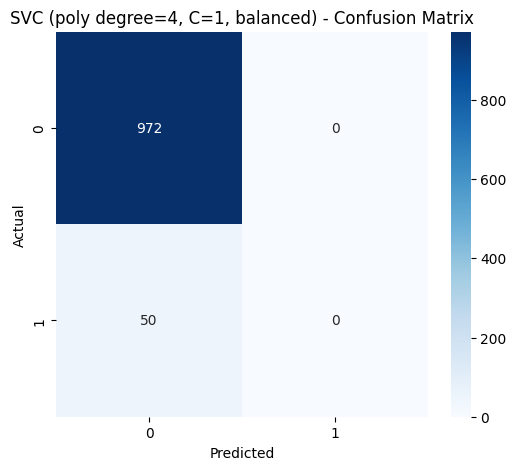

In [105]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (poly degree=4, C=1, balanced) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [106]:
model_svc3 = SVC(kernel='rbf',C=1, gamma='auto',class_weight='balanced')
model_svc3.fit(x_train_processed,y_train)
y_pred_train_svc3=model_svc3.predict(x_train_processed)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.7342794225593344
Testing Accuracy: 0.723091976516634
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.72      0.83       972
           1       0.13      0.80      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.72      0.80      1022

R2 Score: 0.723091976516634


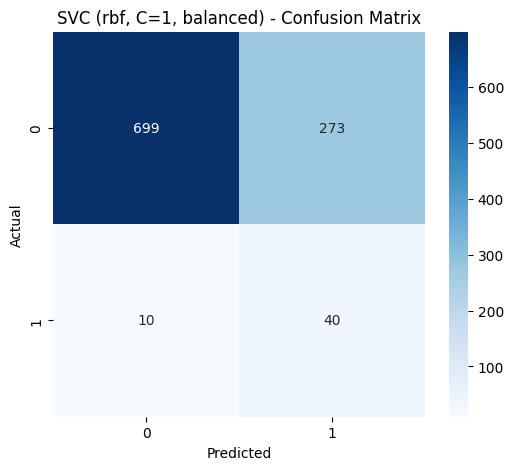

In [107]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (rbf, C=1, balanced) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [42]:
model_svc2 = SVC(kernel='linear',C=10,class_weight='balanced')
model_svc2.fit(x_train_processed,y_train)
y_pred_train_svc2=model_svc2.predict(x_train_processed)
y_pred_test_svc2=model_svc2.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc2))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc2))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc2))
print("R2 Score:", model_svc2.score(x_test_processed, y_test))

Training Accuracy: 0.7619280645950575
Testing Accuracy: 0.7759295499021527
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.78      0.87       972
           1       0.15      0.74      0.24        50

    accuracy                           0.78      1022
   macro avg       0.56      0.76      0.56      1022
weighted avg       0.94      0.78      0.84      1022

R2 Score: 0.7759295499021527


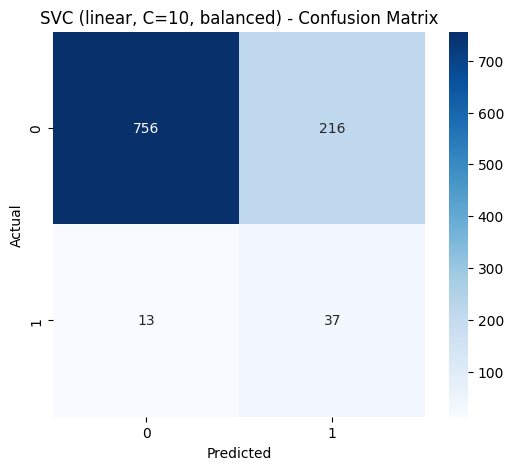

In [43]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (linear, C=10, balanced) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [44]:
model_svc3 = SVC(kernel='sigmoid',C=1, gamma='auto',class_weight='balanced')
model_svc3.fit(x_train_processed,y_train)
y_pred_train_svc3=model_svc3.predict(x_train_processed)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.6983117200880842
Testing Accuracy: 0.7113502935420744
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.71      0.82       972
           1       0.11      0.68      0.19        50

    accuracy                           0.71      1022
   macro avg       0.54      0.70      0.51      1022
weighted avg       0.93      0.71      0.79      1022

R2 Score: 0.7113502935420744


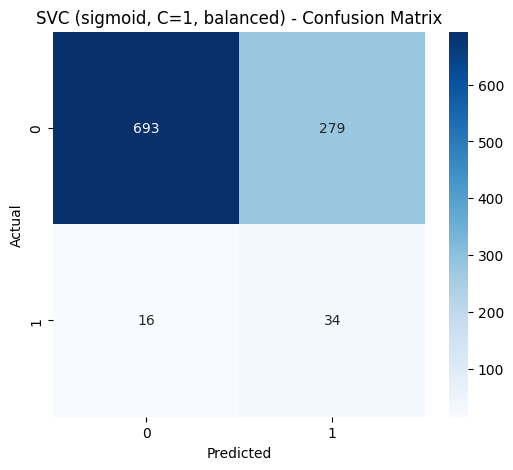

In [45]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (sigmoid, C=1, balanced) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 7 — Handling Class Imbalance with SMOTE

In [60]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(x_train_processed, y_train)
print("After SMOTE:", pd.Series(y_train_resampled).value_counts().to_dict())


Before SMOTE: {0: 3888, 1: 199}
After SMOTE: {0: 3888, 1: 3888}


In [47]:
model= LogisticRegression()
model.fit(X_train_resampled,y_train_resampled)
y_pred_train=model.predict(X_train_resampled)
y_pred_test=model.predict(x_test_processed)

print("Training Accuracy:", accuracy_score(y_train_resampled, y_pred_train))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))
print("Classification Report:\n", classification_report(y_test, y_pred_test))
print("R2 Score:", model.score(x_test_processed, y_test))

Training Accuracy: 0.7849794238683128
Testing Accuracy: 0.7093933463796478
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.70      0.82       972
           1       0.13      0.84      0.22        50

    accuracy                           0.71      1022
   macro avg       0.56      0.77      0.52      1022
weighted avg       0.95      0.71      0.79      1022

R2 Score: 0.7093933463796478


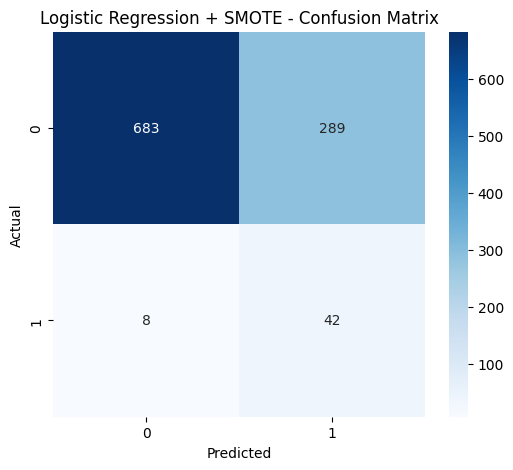

In [48]:
cm_logistic = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression + SMOTE - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### 7.1 — Hyperparameter Tuning (GridSearchCV)

In [49]:
from sklearn.model_selection import GridSearchCV

In [50]:
grid_pram={
    "C":[0.01,0.1,1,10,100],
    'gamma':['auto','scale'],
    'kernel':['linear','poly','rbf','sigmoid']
}
grid=GridSearchCV(SVC(),param_grid=grid_pram,verbose=5)
grid.fit(X_train_resampled,y_train_resampled)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 1/5] END .C=0.01, gamma=auto, kernel=linear;, score=0.743 total time=   1.1s
[CV 2/5] END .C=0.01, gamma=auto, kernel=linear;, score=0.771 total time=   1.1s
[CV 3/5] END .C=0.01, gamma=auto, kernel=linear;, score=0.751 total time=   1.4s
[CV 4/5] END .C=0.01, gamma=auto, kernel=linear;, score=0.737 total time=   2.0s
[CV 5/5] END .C=0.01, gamma=auto, kernel=linear;, score=0.774 total time=   1.9s
[CV 1/5] END ...C=0.01, gamma=auto, kernel=poly;, score=0.605 total time=   2.4s
[CV 2/5] END ...C=0.01, gamma=auto, kernel=poly;, score=0.615 total time=   1.7s
[CV 3/5] END ...C=0.01, gamma=auto, kernel=poly;, score=0.630 total time=   1.7s
[CV 4/5] END ...C=0.01, gamma=auto, kernel=poly;, score=0.614 total time=   1.7s
[CV 5/5] END ...C=0.01, gamma=auto, kernel=poly;, score=0.614 total time=   1.7s
[CV 1/5] END ....C=0.01, gamma=auto, kernel=rbf;, score=0.742 total time=   2.7s
[CV 2/5] END ....C=0.01, gamma=auto, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'gamma': ['auto', 'scale'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             verbose=5)

In [51]:
print('Best params:', grid.best_params_)
print('Best score:', grid.best_score_)


Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best score: 0.9429026525264715


In [61]:
model_svc3 = SVC(kernel='rbf',C=100, gamma='scale')
model_svc3.fit(X_train_resampled,y_train_resampled)
y_pred_train_svc3=model_svc3.predict(X_train_resampled)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train_resampled, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.9674639917695473
Testing Accuracy: 0.8825831702544031
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.94       972
           1       0.14      0.26      0.18        50

    accuracy                           0.88      1022
   macro avg       0.55      0.59      0.56      1022
weighted avg       0.92      0.88      0.90      1022

R2 Score: 0.8825831702544031


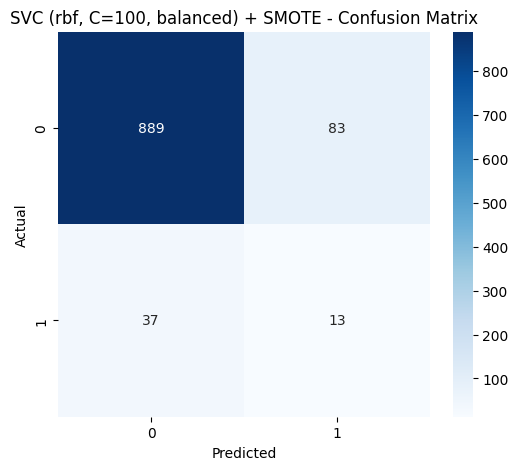

In [62]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (rbf, C=100, balanced) + SMOTE - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


In [127]:
model_svc3 = SVC(kernel='poly',degree=4,C=0.1, gamma='scale')
model_svc3.fit(X_train_resampled,y_train_resampled)
y_pred_train_svc3=model_svc3.predict(X_train_resampled)
y_pred_test_svc3=model_svc3.predict(x_test_processed)


print("Training Accuracy:", accuracy_score(y_train_resampled, y_pred_train_svc3))
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test_svc3))
print("Classification Report:\n", classification_report(y_test, y_pred_test_svc3))
print("R2 Score:", model_svc3.score(x_test_processed, y_test))

Training Accuracy: 0.8037551440329218
Testing Accuracy: 0.8111545988258317
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.82      0.89       972
           1       0.15      0.64      0.25        50

    accuracy                           0.81      1022
   macro avg       0.57      0.73      0.57      1022
weighted avg       0.94      0.81      0.86      1022

R2 Score: 0.8111545988258317


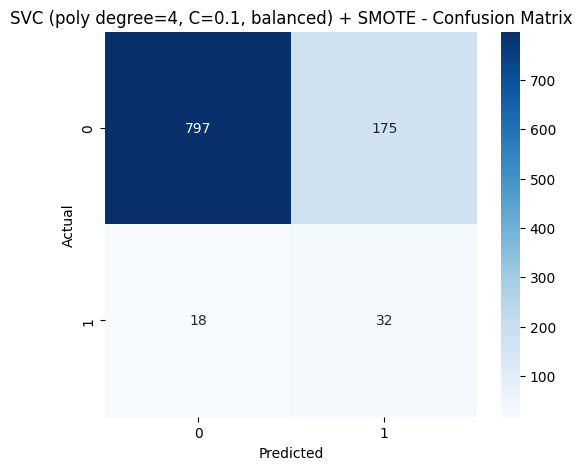

In [128]:
cm_logistic = confusion_matrix(y_test, y_pred_test_svc3)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SVC (poly degree=4, C=0.1, balanced) + SMOTE - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()
